WITHOUT CNN

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

Load MNIST Dataset

In [ ]:
(X_TRAIN, Y_TRAIN), (X_TEST, Y_TEST) = tf.keras.datasets.fashion_mnist.load_data()


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print("Size of X Train " , len(X_TRAIN))
print("Size of Y Train " , len(Y_TRAIN))
print("Size of X Test " , len(X_TEST))
print("Size of Y Test " , len(Y_TEST))


Size of X Train  60000
Size of Y Train  60000
Size of X Test  10000
Size of Y Test  10000


In [ ]:
X_TRAIN.shape

(60000, 28, 28)

In [ ]:
X_TRAIN[0].shape

(28, 28)

In [ ]:
X_TRAIN[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 155, 236, 207, 178, 107, 156, 161, 109,  64,  23,  77, 130,
         72,  15],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
         69, 207, 223, 218, 216, 216, 163, 127, 121, 122, 146, 141,  88,
        172,  66],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   1,   0,
        200, 232, 232, 233, 229, 223, 223, 215, 213, 164, 127, 123, 196,
        229,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        183, 225, 216, 223, 228, 235, 227, 224, 222, 224, 221, 223, 245,
        173,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        193, 228, 218, 213, 198, 180, 212, 210, 211, 213, 223, 220, 243,
        202,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   3,   0,  12,
        219, 220, 212, 218, 192, 169, 227, 208, 218, 224, 212, 226, 197,
        209,  52],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,   0,  99,
        244, 222, 220, 218, 203, 198, 221, 215, 213, 222, 220, 245, 119,
        167,  56],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   4,   0,   0,  55,
        236, 228, 230, 228, 240, 232, 213, 218, 223, 234, 217, 217, 209,
         92,   0],
       [  0,   0,   1,   4,   6,   7,   2,   0,   0,   0,   0,   0, 237,
        226, 217, 223, 222, 219, 222, 221, 216, 223, 229, 215, 218, 255,
         77,   0],
       [  0,   3,   0,   0,   0,   0,   0,   0,   0,  62, 145, 204, 228,
        207, 213, 221, 218, 208, 211, 218, 224, 223, 219, 215, 224, 244,
        159,   0],
       [  0,   0,   0,   0,  18,  44,  82, 107, 189, 228, 220, 222, 217,
        226, 200, 205, 211, 230, 224, 234, 176, 188, 250, 248, 233, 238,
        215,   0],
       [  0,  57, 187, 208, 224, 221, 224, 208, 204, 214, 208, 209, 200,
        159, 245, 193, 206, 223, 255, 255, 221, 234, 221, 211, 220, 232,
        246,   0],
       [  3, 202, 228, 224, 221, 211, 211, 214, 205, 205, 205, 220, 240,
         80, 150, 255, 229, 221, 188, 154, 191, 210, 204, 209, 222, 228,
        225,   0],
       [ 98, 233, 198, 210, 222, 229, 229, 234, 249, 220, 194, 215, 217,
        241,  65,  73, 106, 117, 168, 219, 221, 215, 217, 223, 223, 224,
        229,  29],
       [ 75, 204, 212, 204, 193, 205, 211, 225, 216, 185, 197, 206, 198,
        213, 240, 195, 227, 245, 239, 223, 218, 212, 209, 222, 220, 221,
        230,  67],
       [ 48, 203, 183, 194, 213, 197, 185, 190, 194, 192, 202, 214, 219,
        221, 220, 236, 225, 216, 199, 206, 186, 181, 177, 172, 181, 205,
        206, 115],
       [  0, 122, 219, 193, 179, 171, 183, 196, 204, 210, 213, 207, 211,
        210, 200, 196, 194, 191, 195, 191, 198, 192, 176, 156, 167, 177,
        210,  92],
       [  0,   0,  74, 189, 212, 191, 175, 172, 175, 181, 185, 188, 189,
        188, 193, 198, 204, 209, 210, 210, 211, 188, 188, 194, 192, 216,
        170,   0],
       [  2,   0,   0,   0,  66, 200, 22

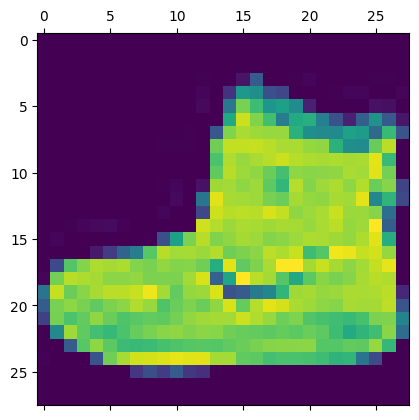

In [ ]:
plt.matshow(X_TRAIN[0])

In [ ]:
Y_TRAIN[0]

np.uint8(9)

In [ ]:
X_TEST[4]

array([[  0,   0,   0,   2,   0,   1,   1,   0,   0,   0,   0,  57,  67,
         73,  76,  76,  83,  62,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   1,   1,   1,   0,   0,  13,  79, 128, 201, 162,
        161, 173, 192, 172, 181, 184, 108,  30,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   1,   0,   0, 102, 139, 142, 103, 115, 162,
        154, 165, 153, 139, 129, 150, 138, 171, 161,  26,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   1,   0,   0, 106, 124, 108, 103, 106,  93, 100,
        180, 156, 147, 138,  85, 157, 114, 124, 154, 157,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   2,   0,  29, 134, 101, 113, 108,  97, 116,  81,
        146, 183, 164, 111, 146, 131, 122, 132, 145, 169,  93,   0,   1,
          0,   0],
       [  0,   0,   0,   0,   0,  65, 131, 105, 101, 108, 100, 104,  97,
         74, 206, 174, 115, 150, 108, 119, 146, 152, 162, 141,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 108, 123, 112, 106,  98, 100, 101, 111,
         72, 136, 132, 112, 115, 109, 142, 150, 160, 162, 195,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 135, 122, 119, 112,  83,  93,  97, 106,
        115,  91, 109,  83, 109, 125, 165, 140, 193, 160, 176,   6,   0,
          0,   0],
       [  0,   0,   0,   0,  23, 135, 132, 149, 104,  78,  96,  97, 103,
        108, 108, 115,  84, 114, 149, 158, 147, 209, 160, 178,  52,   0,
          0,   0],
       [  0,   0,   0,   0,  57, 124, 131, 160, 103,  96, 101, 109, 109,
        111, 108, 114, 106, 113, 156, 163, 156, 196, 167, 174,  85,   0,
          0,   0],
       [  0,   0,   0,   0,  86, 116, 126, 160, 132, 102,  96, 104, 107,
         98,  93, 123, 116, 112, 149, 160, 181, 186, 162, 162, 123,   0,
          0,   0],
       [  0,   0,   0,   0, 112, 114, 112, 167, 146, 100, 100, 101, 107,
         96, 100, 126, 103, 120, 141, 158, 167, 187, 147, 148, 170,   0,
          0,   0],
       [  0,   0,   0,   0, 124, 118, 101, 197,  89, 101, 100,  96, 108,
        103, 108, 122, 107, 127, 139, 150, 119, 196, 145, 142, 179,   0,
          0,   0],
       [  0,   0,   0,   0, 131, 115,  97, 198,  47, 108,  96,  96, 106,
        119, 102, 120, 103, 123, 140, 150,  81, 206, 146, 135, 194,   0,
          0,   0],
       [  0,   0,   0,   4, 136, 118,  98, 193,  21, 109,  96, 106, 102,
        129, 100, 119, 102, 118, 141, 153,  45, 216, 148, 139, 205,  12,
          0,   0],
       [  0,   0,   0,  24, 137, 117, 101, 187,  25, 113,  92, 112,  94,
        120, 105, 127,  97, 115, 142, 150,  19, 213, 148, 131, 204,  36,
          0,   0],
       [  0,   0,   0,  40, 141, 109, 117, 158,  12, 124,  90, 116,  96,
        117, 113, 136,  94, 111, 147, 163,  31, 191, 146, 134, 206,  58,
          0,   0],
       [  0,   0,   0,  39, 129, 102, 147, 119,   0, 120,  90, 119, 101,
        116, 106, 127, 102, 114, 146, 180,  20, 146, 159, 129, 204,  70,
          0,   0],
       [  0,   0,   0,  58, 126, 111, 162, 101,  21, 132,  89, 123, 108,
        106, 102, 126, 111, 116, 141, 178,  50, 112, 169, 138, 164,  84,
          0,   0],
       [  0,   0,   0, 108, 134, 134, 185,  84,  73, 123,  87, 122, 111,
        102, 106, 128, 114, 109, 134, 174,  97,  98, 160, 147, 175, 135,
          0,   0],
       [  0,   0,   0,  97, 142, 169, 198,  37,  84, 107,  97, 122, 112,
        109, 112, 126, 102,  96, 131, 172, 128,  51, 254, 168, 164, 111,
          0,   0],
       [  0,   0,   0,   0,   0,  12,  46,   2, 119, 102, 109, 123,  96,
        116, 122, 132, 106, 106, 129, 151, 184,  26,  20,   8,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  13, 137, 101, 114, 100, 106,
        134, 135, 129, 104, 111, 123, 151, 194,  74,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   1,   3,   0,  73, 132, 101, 104, 102, 140,
        108, 108, 131, 106, 119, 113, 142, 167, 135,   0,   1,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

Data Preprocessing Normalize (0–255 → 0–1)

In [ ]:
X_TRAIN = X_TRAIN / 255.0
X_TEST = X_TEST / 255.0

DNN (Dense Neural Network)

Flatten **Data**

In [ ]:
X_TRAIN_FLATEN = X_TRAIN.reshape(len(X_TRAIN), 28 * 28)
X_TEST_FLATEN = X_TEST.reshape(len(X_TEST), 28 * 28)

In [ ]:
type (X_TRAIN_FLATEN)

numpy.ndarray

In [ ]:
type (X_TRAIN)

numpy.ndarray

In [ ]:
X_TRAIN_FLATEN.shape

(60000, 784)

In [ ]:
X_TEST_FLATEN.shape

(10000, 784)

Build DNN Model

In [ ]:
dnn_model = models.Sequential([layers.Dense(128, activation='relu',
input_shape=(X_TRAIN_FLATEN.shape[1],)),
layers.Dense(64, activation='relu'),
layers.Dense(10, activation='softmax') ])

In [ ]:
dnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Compile Model

In [ ]:
dnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',  metrics=['accuracy'] )

In [ ]:
history_dnn = dnn_model.fit(    X_TRAIN_FLATEN, Y_TRAIN,    epochs=10,    batch_size=32,    validation_split=0.2 )

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8984 - loss: 0.2735 - val_accuracy: 0.8727 - val_loss: 0.3437
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9009 - loss: 0.2596 - val_accuracy: 0.8809 - val_loss: 0.3336
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9059 - loss: 0.2485 - val_accuracy: 0.8823 - val_loss: 0.3380
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9094 - loss: 0.2396 - val_accuracy: 0.8861 - val_loss: 0.3217
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9113 - loss: 0.2322 - val_accuracy: 0.8868 - val_loss: 0.3286
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9155 - loss: 0.2229 - val_accuracy: 0.8805 - val_loss: 0.3591
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9174 - loss: 0.2181 - val_accuracy: 0.8906 - val_loss: 0.3229
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9211 - loss: 0.2098 -

In [ ]:
test_loss, test_acc = dnn_model.evaluate(X_TEST_FLATEN, Y_TEST)
print("DNN Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8839 - loss: 0.3669
DNN Test Accuracy: 0.883899986743927


In [ ]:
pred = dnn_model.predict(X_TEST_FLATEN)
pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[1.7352990e-08, 4.2702172e-10, 2.5378597e-06, ..., 1.8313518e-03,
        2.5489904e-08, 9.9806219e-01],
       [1.8011885e-04, 1.0606814e-13, 9.9448788e-01, ..., 4.6079398e-07,
        7.0950212e-10, 2.3764588e-09],
       [1.0599059e-18, 9.9999994e-01, 8.0648095e-28, ..., 3.8936607e-27,
        1.1544793e-16, 2.0605210e-20],
       ...,
       [2.2421607e-04, 4.7780868e-10, 4.3213106e-07, ..., 3.3690700e-10,
        9.9974859e-01, 1.5213136e-13],
       [6.5616015e-12, 9.9999994e-01, 1.1780984e-16, ..., 3.3218969e-20,
        1.2499788e-09, 3.2431839e-15],
       [1.1706376e-08, 4.0252650e-09, 5.3728268e-08, ..., 1.0598928e-05,
        1.0420157e-05, 6.5828969e-09]], dtype=float32)

In [ ]:
import numpy as np
data_prediction = np.argmax(pred, axis=1)
data_prediction

array([9, 2, 1, ..., 8, 1, 5])

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score
print("Accuracy :", accuracy_score(Y_TEST, data_prediction))
print("Precision:", precision_score(Y_TEST, data_prediction, average='weighted'))
print("Recall   :", recall_score(Y_TEST, data_prediction, average='weighted'))
print("F1 Score :", f1_score(Y_TEST, data_prediction, average='weighted'))

Accuracy : 0.8839
Precision: 0.8840903300242633
Recall   : 0.8839
F1 Score : 0.8836023554742584


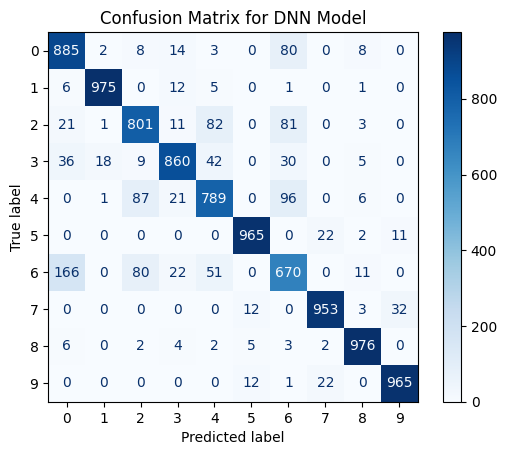

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_TEST, data_prediction)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix for DNN Model")
plt.show()

------------


-------



In [ ]:
import tensorflow as tf
from tensorflow.keras import layers,models
import matplotlib.pyplot as plt

In [ ]:
from tensorflow.keras import datasets

#(X_TRAIN, Y_TRAIN), (X_TEST, Y_TEST) = datasets.cifar10.load_data()
(X_TRAIN, Y_TRAIN), (X_TEST, Y_TEST) = tf.keras.datasets.fashion_mnist.load_data()

print("Train shape",X_TRAIN.shape)
print("Test shape", X_TEST.shape)

Train shape (60000, 28, 28)
Test shape (10000, 28, 28)


In [ ]:
X_TRAIN=X_TRAIN /255.0
X_TEST=X_TEST /255.0

In [ ]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

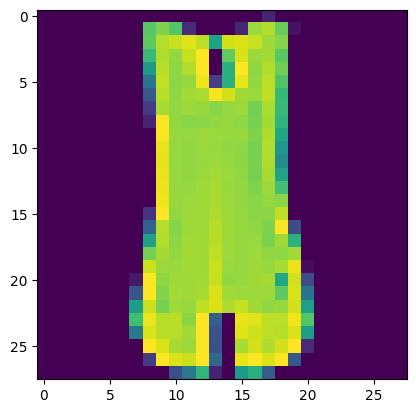

In [ ]:
plt.imshow(X_TRAIN[4])
plt.show()

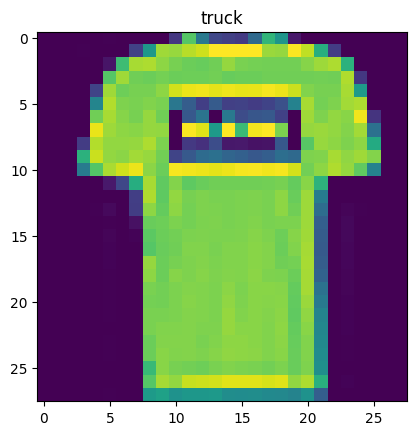

In [ ]:
plt.imshow(X_TRAIN[1])
plt.title(class_names[Y_TRAIN[0]])
plt.show()

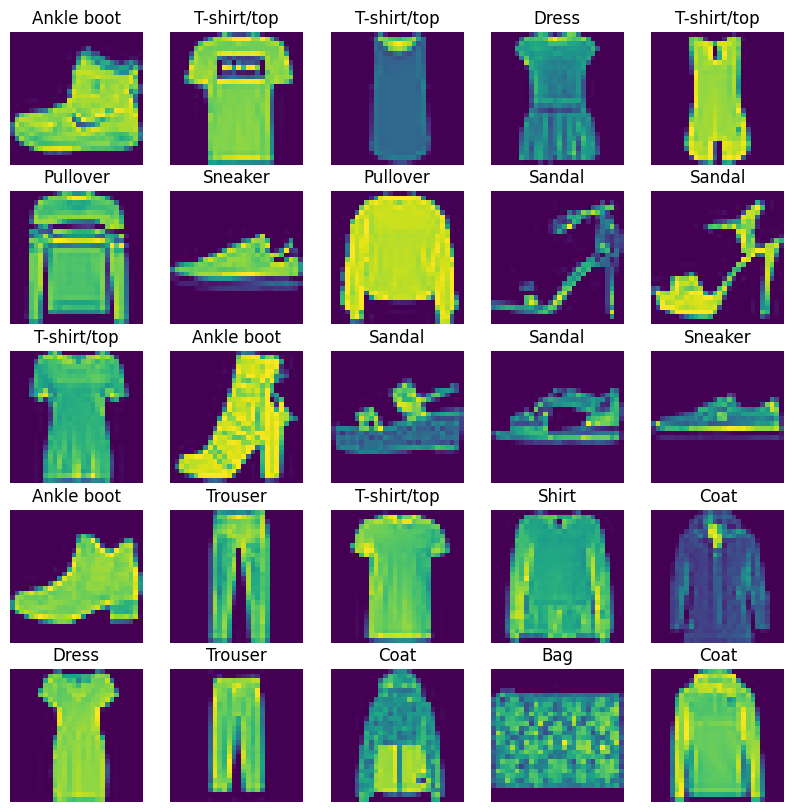

In [ ]:
plt.figure(figsize=(10,10))
for i in range(25): #show 25 img
    plt.subplot(5,5,i+1)
    plt.title(class_names[Y_TRAIN[i]]) # Corrected: Y_TRAIN[i][0] to Y_TRAIN[i]
    plt.imshow(X_TRAIN[i])
    plt.axis('off')
plt.show()

In [ ]:
X_TRAIN = X_TRAIN.reshape((X_TRAIN.shape[0], 28, 28, 1))
X_TEST = X_TEST.reshape((X_TEST.shape[0], 28, 28, 1))
print(X_TRAIN.shape)

(60000, 28, 28, 1)


In [ ]:
model=tf.keras.models.Sequential()
model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64,activation='relu'))
model.add(layers.Dense(10))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])

In [ ]:
history=model.fit(X_TRAIN,Y_TRAIN,epochs=10,validation_data=(X_TEST,Y_TEST))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.8152 - loss: 0.5003 - val_accuracy: 0.8626 - val_loss: 0.3756
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.8845 - loss: 0.3181 - val_accuracy: 0.8878 - val_loss: 0.3205
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.8999 - loss: 0.2740 - val_accuracy: 0.8903 - val_loss: 0.2955
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9097 - loss: 0.2444 - val_accuracy: 0.9008 - val_loss: 0.2715
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.9193 - loss: 0.2200 - val_accuracy: 0.9070 - val_loss: 0.2607
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 31ms/step - accuracy: 0.9257 - loss: 0.2018 - val_accuracy: 0.8995 - val_loss: 0.2776
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.9314 - loss: 0.1858 - val_accuracy: 0.9088 - val_loss: 0.2599
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9362 -

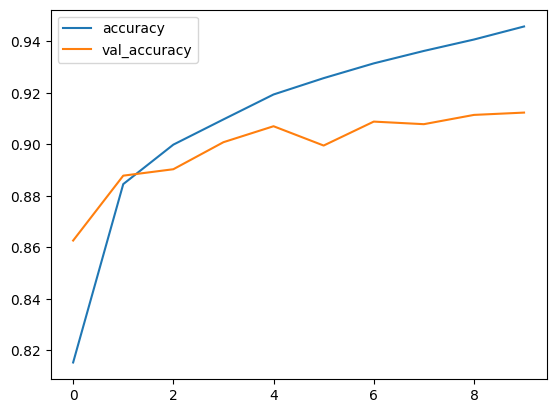

In [ ]:
plt.plot  (history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.legend()
plt.show()

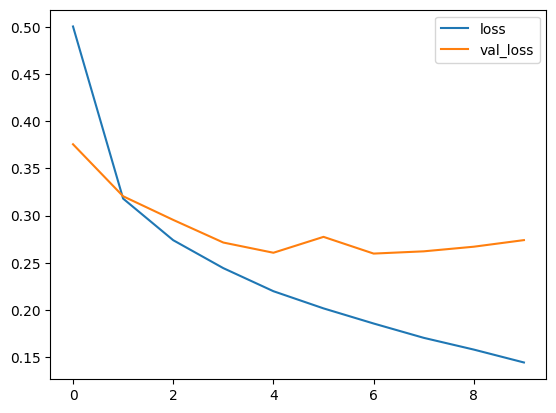

In [ ]:
plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.legend()
plt.show()

In [ ]:
predictions=model.predict(X_TEST)
predictions

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


array([[ -9.483657 ,  -6.769846 ,  -9.718668 , ...,  -0.6340661,
         -6.143126 ,  11.208633 ],
       [  1.6101707, -13.381711 ,  11.843681 , ..., -18.299326 ,
         -8.993483 , -11.13831  ],
       [ -7.8255925,  26.563524 ,  -6.7757163, ..., -23.111994 ,
        -13.726261 , -30.703194 ],
       ...,
       [ -6.717622 , -13.088603 ,  -6.330078 , ..., -13.17097  ,
         25.145773 ,  -4.86245  ],
       [ -4.5562773,  20.318136 ,  -5.903099 , ..., -20.766888 ,
        -15.307318 , -25.70665  ],
       [ -9.207301 ,  -7.9922485,  -7.556248 , ...,  -1.1579832,
         -4.782085 ,  -3.0449128]], dtype=float32)

In [ ]:
import numpy as np
data_predictions =np.argmax(predictions,axis=1)
print(data_predictions)
print(data_predictions.shape)

[9 2 1 ... 8 1 5]
(10000,)


In [ ]:
print("predicted:",class_names[data_predictions[11]])
print("Actual:",class_names[Y_TEST[11]])

predicted: Sandal
Actual: Sandal
